# Лабораторная работа 2. Обучение с учителем. Задача регрессии

In [302]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from math import sqrt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

### Загрузка данных

In [303]:
data = pd.read_csv('../data/final_data_diamonds.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)

### Первый шаг: выделение целевого признака и предикторов

In [304]:
y = data["price"]
X = data.drop(["price"], axis=1)
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64

In [305]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,0.373383,0.346954,0.290021


### Второй шаг: разделение данных на обучающую и тестовую выборки

In [306]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [307]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((43152, 9), (43152,), (10788, 9), (10788,))

Итак, данные предобработаны, целевой признак выделен, имеются обучающая и тестовая выборка. Мы готовы приступить к обучению.

### Линейная регрессия (Linear Regression). Постановка задачи

In [308]:
lr = LinearRegression().fit(X_train, y_train)
lr.predict(X_test)

array([ 275.37812284, 4137.82745854,  394.53451272, ..., 4707.47620304,
       6271.42515464, 3903.39483194], shape=(10788,))

In [309]:
y_pred = lr.predict(X_test)

In [310]:
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')

MAE: 798.67
MSE: 1453096.35
RMSE: 1205.44
MAPE: 0.66
R^2: 0.91


In [311]:
len(lr.coef_)
lr.coef_

array([ 5189.02735152,   126.80218774,   324.4778493 ,   499.84101968,
         -92.90360552,   -52.56846436, -1560.36688856,   638.04119341,
        -128.34713297])

In [312]:
# L1
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 798.72
MSE: 1453115.01
RMSE: 1205.45
MAPE: 0.66
R^2: 0.91


array([ 5187.40994598,   126.78060686,   324.45705332,   499.8693118 ,
         -92.79423826,   -52.60090469, -1554.31570754,   633.9934989 ,
        -128.75757378])

In [313]:
# L2
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 799.15
MSE: 1454306.09
RMSE: 1205.95
MAPE: 0.66
R^2: 0.91


array([ 5171.14521747,   125.78681913,   324.15919524,   500.44382986,
         -96.28063277,   -53.80541144, -1378.54211732,   444.79941798,
         -98.79809032])

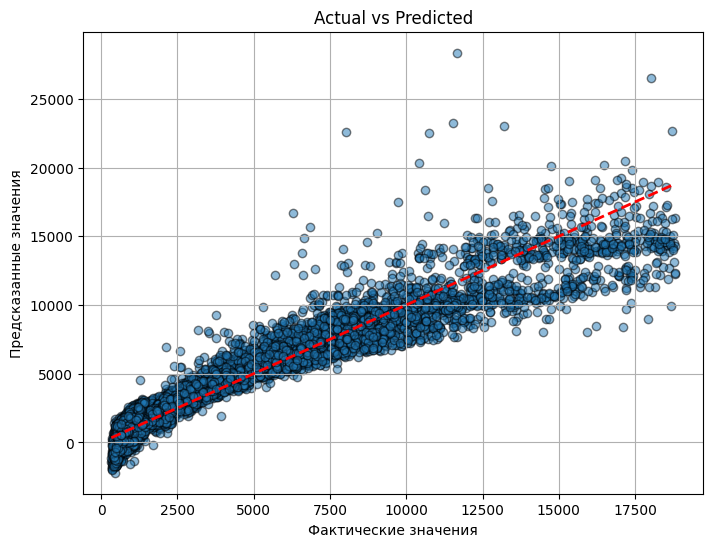

In [314]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

In [315]:
parameters = {'alpha': np.arange(0, 1, 0.1)}    

In [316]:
ridge_optimal = GridSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [317]:
ridge_optimal = RandomizedSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [318]:
ridge_final = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)

In [319]:
# L1
ridge = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 798.76
MSE: 1453130.00
RMSE: 1205.46
MAPE: 0.66
R^2: 0.91


array([ 5186.11789165,   126.7635158 ,   324.44041571,   499.89181534,
         -92.706916  ,   -52.62652479, -1549.50820999,   630.78442424,
        -129.08349822])

In [320]:
# L2
lasso = Lasso(alpha=0.9).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 799.62
MSE: 1455420.43
RMSE: 1206.41
MAPE: 0.66
R^2: 0.91


array([ 5156.89287695,   124.97398   ,   323.90451107,   500.92491068,
         -99.00262153,   -54.79589934, -1233.16673624,   290.10274372,
         -75.02415526])